In [ ]:
## Data generated by Sergeev et al. (2025)

In [ ]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.calc
import aeolus.coord

In [2]:
p_5 = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_0p5bar-pr92-time-ave-prof.nc')
p_5

/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


[<iris 'Cube' of air_pressure / (Pa) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of air_temperature / (K) (model_level_number: 63; latitude: 144; longitude: 97)>,
<iris 'Cube' of cloud_ice_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of cloud_liquid_water_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of humidity_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of relative_humidity / (%) (model_level_number: 63; latitude: 144; longitude: 97)>,
<iris 'Cube' of upward_air_velocity / (m s-1) (model_level_number: 63; latitude: 144; longitude: 97)>]

In [3]:
## Extract P and T cubes and reduce cubes to their temporal means (from 4D to 3D)

air_temperature = p_5.extract_cube('m01s16i004')
airtemp_mean = air_temperature.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

air_pressure = p_5.extract_cube('m01s00i408')
airpressure_mean = air_pressure.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

rel_humid = p_5.extract_cube('m01s30i113')
rel_humid_mean = rel_humid.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)


## Calculate sigma pressure (sigma = air_pressure / surface_pressure), converting to Pa

surface_pressure_bar = 0.5
sigma_pressure = airpressure_mean/(surface_pressure_bar*100000)


## Retrieving and flattening the data points for air temperature and air pressure
## Using log_10(sigma_pressure) instead as looking at hydrostatic equation, height is proportional to log of pressure with constants R, g and average T in a layer of atmosphere

AIRTEMP_FLAT = (airtemp_mean.data).flatten()
temps = AIRTEMP_FLAT

SIG_AIRPRESSURE_FLAT = (sigma_pressure.data).flatten()
log10_sig_pressures = np.log10(SIG_AIRPRESSURE_FLAT[:63])

REL_HUMID_FLAT = (rel_humid_mean.data).flatten()
rel_humids = REL_HUMID_FLAT

print(len(temps), len(log10_sig_pressures), len(rel_humids))
# print(log10_sig_pressures)

63 63 63


/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighti

In [4]:
# ## Air temperature as a function of height (model level number), optional plot

# iplt.plot(airtemp_mean)
# plt.xlabel('Temperature / K')
# plt.ylabel('Altitude / m')
# plt.grid()
# plt.show()

In [5]:
# ## Air pressure as a function of height (model level number), optional plot

# iplt.plot(sigma_pressure)
# plt.xlabel(r'$\sigma$')
# # plt.gca().invert_yaxis()
# plt.ylabel('Altitude / m')
# plt.grid()
# plt.show()

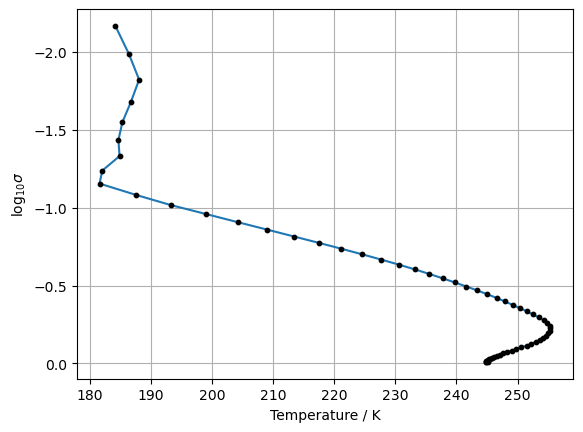

In [6]:
## Plot the temperature profile wrt log_10(sigma), note that the y-axis naturally follows a log scale

plt.plot(temps, log10_sig_pressures)
plt.scatter(temps, log10_sig_pressures, s = 10, facecolor = 'black', zorder = 3)
plt.gca().invert_yaxis()
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
plt.grid()
plt.show()

In [7]:
## This is for finding where the troposphere/stratosphere/mesosphere layers start and end in the code (via indexing)
print('Stratosphere: ', np.array(np.where(log10_sig_pressures<-1))) 
print('Mesosphere: ', np.array(np.where(log10_sig_pressures<-2))) 
print('Troposphere: ', np.array(np.where(log10_sig_pressures > -1)))
print(log10_sig_pressures[0], log10_sig_pressures[29], log10_sig_pressures[30], log10_sig_pressures[37])

Stratosphere:  [[52 53 54 55 56 57 58 59 60 61 62]]
Mesosphere:  [[62]]
Troposphere:  [[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
  24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
  48 49 50 51]]
-0.00999825 -0.29524362 -0.31436124 -0.46854562


In [8]:
sig_p = np.arange(-3.8, 0, 0.01)
t = np.zeros(len(sig_p))

def temp_strat(sigma_p):
    if sigma_p > -0.9: #Troposphere
        # return tropfunction(sigma_p)
        return 120.5718357 * sigma_p + 285.47827322
    elif sigma_p > -2.25: # Stratosphere
        # return stratfunction(sigma_p)
        return 2.53197122e+01 * sigma_p**9 + 5.49418784e+02 * sigma_p**8 + 5.14741161e+03 * sigma_p**7 + 2.72999043e+04 * sigma_p**6 + 9.02416549e+04 * sigma_p**5 + 1.92643072e+05 * sigma_p**4 + 2.65380745e+05 * sigma_p**3 + 2.27337528e+05 * sigma_p **2 + 1.09834926e+05 * sigma_p + 2.29695343e+04
    else: # Mesosphere
        # return mesofunction(sigma_p)
        return 3.82949073e-03 * sigma_p**9 +  2.43852764e-03 * sigma_p**8 - 5.08313646e-02 * sigma_p**7 +  2.03902500e-01 * sigma_p**6 - 1.93617933e-01 * sigma_p**5 - 2.60371250e+00 * sigma_p**4 + 1.50749300e+01 * sigma_p**3 - 4.68621587e+00 * sigma_p**2 - 2.79833145e+02 * sigma_p - 2.43661521e+02
    
for i in range(len(sig_p)):
    pressure = sig_p[i]
    t[i] = temp_strat(pressure)

In [9]:
tenbar_sigmas = np.loadtxt('/data/cluster4/jj22956/pr92_thunderstruck_files/tenbar_sigmas.txt')
tenbar_temps = np.loadtxt('/data/cluster4/jj22956/pr92_thunderstruck_files/tenbar_temps.txt')

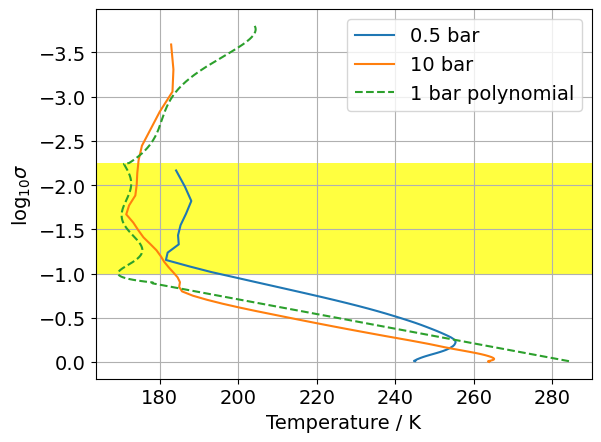

In [10]:
plt.rcParams.update({'font.size': 14})

plt.plot(temps, log10_sig_pressures, label='0.5 bar') # Original data
plt.plot(tenbar_temps, tenbar_sigmas, label='10 bar') # Original datastrat_high = np.log10(0.006)
plt.plot(t, sig_p, '--', label='1 bar polynomial') # Plot produced by the double-polynomial function
strat_low = - 1
strat_high = -2.25
plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend()
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/1bar_10bar_polynomial_airtemp.pdf')
plt.show()

In [11]:
p5bar_sigmas = np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/p5_sigmas.txt', log10_sig_pressures)
p5bar_temps = np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/p5_temps.txt', temps)

In [12]:
# plt.plot(rel_humids, log10_sig_pressures)
# plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
# plt.xlabel('Relative Humidity / %')
# plt.ylabel(r'log$_{10}\sigma$')
# plt.title('TRAPPIST-1e Relative Humidity (0.5 bar surface pressure)')
# plt.legend()
# plt.grid()
# plt.show()